In [45]:
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import OpenAIEmbeddings
# from langchain_core import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.chat_models import ChatOpenAI

from langgraph.graph import StateGraph , START , END
from typing_extensions import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
import os
from dotenv import load_dotenv
from langchain_core.documents import Document

load_dotenv()

True

In [46]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

model = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [47]:
model.invoke("My name is MAnan what your name")

AIMessage(content='Hello, MAnan! I’m an AI and don’t have a personal name, but you can call me Assistant. How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 16, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini', 'system_fingerprint': 'fp_3d695acdac', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da9c6-c037-7ff1-8db0-8da1dc9d3f67-0', tool_calls=[], invalid_tool_calls=[])

In [48]:
url = ['https://en.wikipedia.org/wiki/AI_agent']

doc = []
loader = WebBaseLoader(url)
data = loader.load()
doc.extend(data)



In [49]:
doc[0].page_content

'\n\n\n\nAI agent - Wikipedia\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nJump to content\n\n\n\n\n\n\n\nMain menu\n\n\n\n\n\nMain menu\nmove to sidebar\nhide\n\n\n\n\t\tNavigation\n\t\n\n\nMain pageContentsCurrent eventsRandom articleAbout WikipediaContact us\n\n\n\n\n\n\t\tContribute\n\t\n\n\nHelpLearn to editCommunity portalRecent changesUpload fileSpecial pages\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\nSearch\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nAppearance\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nDonate\n\nCreate account\n\nLog in\n\n\n\n\n\n\n\n\nPersonal tools\n\n\n\n\n\n\nDonate\n\n\nCreate account\n\n\nLog in\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nContents\nmove to sidebar\nhide\n\n\n\n\n(Top)\n\n\n\n\n\n1\nOverview\n\n\n\n\n\n\n\n\n2\nHistory\n\n\n\n\n\n\n\n\n3\nTraining and testing\n\n\n\n\n\n\n\n\n4\nAutonomous capabilities\n\n\n\n\n\n\n\n\n5\nCognitive architecture\n\n\n\n\nToggle Cognitive architecture subsection\

In [50]:
import re

clear_output = re.sub(r'[^A-Za-z .,!?]\s+', '', doc[0].page_content)

In [51]:
doc[0].page_content = clear_output


In [52]:
doc

[Document(metadata={'source': 'https://en.wikipedia.org/wiki/AI_agent', 'title': 'AI agent - Wikipedia', 'language': 'en'}, page_content='AI agent WikipediaJump to contentMain menuMain menu\nmove to sidebar\nhideNavigationMain pageContentsCurrent eventsRandom articleAbout WikipediaContact usContributeHelpLearn to editCommunity portalRecent changesUpload fileSpecial pagesSearchSearchAppearanceDonateCreate accountLog inPersonal toolsDonateCreate accountLog inContents\nmove to sidebar\nhide(TopOverviewHistoryTraining and testingAutonomous capabilitiesCognitive architectureToggle Cognitive architecture subsection5.Reference architectureOrchestration patternsMultimodal AI agentsApplicationsToggle Applications subsection8.Applications in government8.Operating systems8.Web browsingProposed benefits1ConcernsToggle Concerns subsection10.Agentic misalignment1SecurityToggle Security subsection11.Threat modeling frameworks1See also1ReferencesToggle the table of contentsAI agent1languagesAfrikaansব

In [53]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
split_doc = splitter.split_documents(doc)



In [54]:
vector_store = FAISS.from_documents(split_doc, embeddings)


retriever = vector_store.as_retriever()

In [55]:
retriever.invoke("What is an AI agent?")

[Document(id='26065de2-585e-494f-bdd1-24c30436d5a4', metadata={'source': 'https://en.wikipedia.org/wiki/AI_agent', 'title': 'AI agent - Wikipedia', 'language': 'en'}, page_content="tools or planning systems. Their control flow is frequently driven by large language models (LLMs). Agents also include memory systems for remembering previous user-agent interactions and orchestration software for organizing agent components.[2AI agents do not have a standard definition.[3][4][5The concept of agentic AI has been compared to the fictional character J.A.R.V.I.S..[6A common application of AI agents is the automation of tasks, for example booking travel plans based on a user's"),
 Document(id='267725b9-a626-4b99-87dd-7abf86f549b9', metadata={'source': 'https://en.wikipedia.org/wiki/AI_agent', 'title': 'AI agent - Wikipedia', 'language': 'en'}, page_content='distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-making over content cr

In [56]:
class RAG(BaseModel):
    question: str = Field(default="What is an AI agent?")
    answer: str = ""
    retrieved_docs: list[Document] = []

In [57]:
def retriever_document(state: RAG) -> RAG:
    question = state.question
    doc = retriever.invoke(question)
    return RAG(question=question, retrieved_docs=doc)

def generate_answer(state: RAG) -> RAG:
    context = "\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the following context:\n\n{context}\n\nQuestion: {state.question}\nAnswer:"
    answer = model.invoke(prompt)
    return RAG(question=state.question, retrieved_docs=state.retrieved_docs, answer=answer.content)


In [60]:
graph = StateGraph(RAG)

graph.add_node("retriever", retriever_document)
graph.add_node("generator", generate_answer)
graph.add_edge(START, 'retriever')
graph.add_edge("retriever", "generator")
graph.add_edge("generator", END)

result = graph.compile()

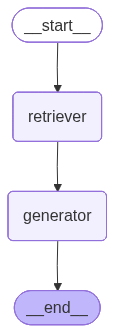

In [61]:
result

In [65]:
result = result.invoke({"question": "What are usecase of the AI agent?"})

In [66]:
result['answer']

'AI agents have several use cases, including:\n\n1. **Task Automation**: They can automate repetitive tasks, such as booking travel plans based on user requests.\n2. **Personal and Economic Productivity**: AI agents are posited to increase productivity by handling monotonous tasks, allowing users to focus on more complex activities.\n3. **Web Accessibility**: They can assist individuals with disabilities by improving access to online resources and services.\n4. **Disaster Response Coordination**: AI agents can be utilized to coordinate resources and manage logistics during disaster response efforts.\n5. **Enhancing Human Capabilities**: Rather than replacing humans, AI agents can enhance human decision-making and efficiency, particularly in situations with uncertain goals.\n\nThese applications highlight the versatility of AI agents in various domains, from personal assistance to critical response scenarios.'

In [68]:
from IPython.display import Markdown, display

display(Markdown(f"### Answer\n\n{result['answer']}"))

### Answer

AI agents have several use cases, including:

1. **Task Automation**: They can automate repetitive tasks, such as booking travel plans based on user requests.
2. **Personal and Economic Productivity**: AI agents are posited to increase productivity by handling monotonous tasks, allowing users to focus on more complex activities.
3. **Web Accessibility**: They can assist individuals with disabilities by improving access to online resources and services.
4. **Disaster Response Coordination**: AI agents can be utilized to coordinate resources and manage logistics during disaster response efforts.
5. **Enhancing Human Capabilities**: Rather than replacing humans, AI agents can enhance human decision-making and efficiency, particularly in situations with uncertain goals.

These applications highlight the versatility of AI agents in various domains, from personal assistance to critical response scenarios.